In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Confidense intervals: using t procedure

**Titanic dataset : Central Limit Theorem on "Fare" column** 

In [6]:
train_df = pd.read_csv("../datasets/train_kaggle.csv")
test_df = pd.read_csv("../datasets/test_kaggle.csv")

In [3]:
df = pd.concat([train_df.drop(columns=["Survived"]),test_df]).sample(1309)   #1309 total rows hai to use shuffle kredenge for smapling distribution

In [4]:
df

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
465,466,3,"Goncalves, Mr. Manuel Estanslas",male,38.0,0,0,SOTON/O.Q. 3101306,7.0500,NaN,S
333,334,3,"Vander Planke, Mr. Leo Edmondus",male,16.0,2,0,345764,18.0000,NaN,S
357,358,2,"Funk, Miss. Annie Clemmer",female,38.0,0,0,237671,13.0000,NaN,S
847,848,3,"Markoff, Mr. Marin",male,35.0,0,0,349213,7.8958,NaN,C
169,1061,3,"Hellstrom, Miss. Hilda Maria",female,22.0,0,0,7548,8.9625,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
707,708,1,"Calderhead, Mr. Edward Pennington",male,42.0,0,0,PC 17476,26.2875,E24,S
290,291,1,"Barber, Miss. Ellen ""Nellie""",female,26.0,0,0,19877,78.8500,NaN,S
380,1272,3,"O'Connor, Mr. Patrick",male,NaN,0,0,366713,7.7500,NaN,Q
794,795,3,"Dantcheff, Mr. Ristiu",male,25.0,0,0,349203,7.8958,NaN,S


<Axes: ylabel='Density'>

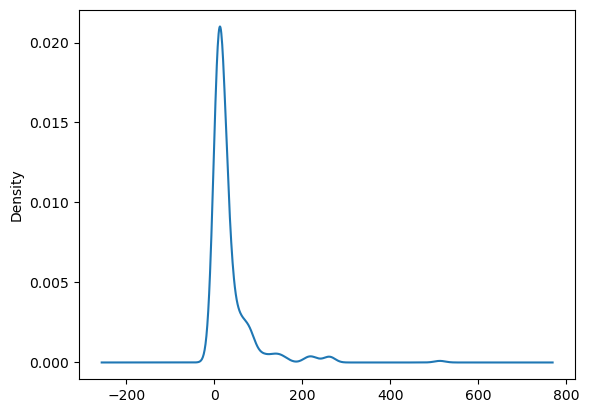

In [5]:
df["Fare"].plot(kind="kde")

In [7]:
# now we perform central limit theorem: no:of trials 10 and sample size =30: ab t procedure mein saare trials se jo std nikle hain unka average lena hai
samples = []
stds = []
for i in range(10):
    x = df["Fare"].dropna().sample(30).values      # isse fare columns ke jo hamne first 30 non null samples liye hai unki values x mein store ho jaayengi 
    stds.append(x.std())     # ab x ke saare trials = 10 jo individually 30 samples se hain unka std lena hai and use stds list mein store krna hai
    samples.append(x.tolist()) 

In [9]:
samples = np.array(samples)
samples

array([[113.275 ,   7.75  ,   8.05  ,  39.    ,  26.    ,  26.    ,
         23.25  ,  26.    ,   6.75  ,  50.    ,  13.    ,  26.    ,
         10.5   ,  46.9   ,  22.025 ,  71.    ,  12.35  ,  52.5542,
         59.4   ,  11.5   ,  16.1   ,   7.2292,  24.    ,  21.    ,
         24.15  ,   8.05  ,  13.    ,  69.55  ,   7.55  , 134.5   ],
       [ 24.15  , 247.5208,   6.95  ,   0.    ,  11.2417,  22.525 ,
        134.5   ,  20.575 ,  20.575 ,   0.    ,   7.925 ,   7.2292,
         21.075 ,  26.55  ,  23.45  ,  13.    ,  18.    ,  26.25  ,
          7.7958,  30.    ,   7.25  ,   8.7125,   7.8958,   7.75  ,
          7.05  ,  13.    ,   7.775 ,  83.1583,   7.2292, 134.5   ],
       [ 77.2875,  22.3583,   7.75  ,   7.225 ,   7.8542,   9.5   ,
          7.775 ,  12.475 ,   8.05  ,   7.775 ,  18.7875,  69.55  ,
        153.4625,   7.8958,  25.4667,  22.525 ,  30.5   ,   8.05  ,
         26.    ,  10.5   ,   6.95  ,  15.9   ,   7.925 ,   7.8958,
         41.5792,  20.575 ,  26.25  ,  14.4583

In [18]:
sampling_mean= np.mean(samples, axis=1)      # ab saare samples and sampling mean nikaalna hai
sampling_mean

array([32.54778   , 31.78777667, 24.73916667, 36.74666333, 23.21819   ,
       41.94139333, 43.45125   , 34.05361333, 31.50986   , 19.32707667])

In [17]:
sample_std = np.mean(stds)   # ab vo resultant jo 10 trials ke baad 10 std aaye hain unka average lena hai
sample_std

np.float64(40.1449372854111)

In [20]:
sample_mean = sampling_mean.mean()   # ab sampling mean ka bhi mean nikalna hai as 10 sampling means hai hamare paas
sample_mean

np.float64(31.932277)

<Axes: ylabel='Density'>

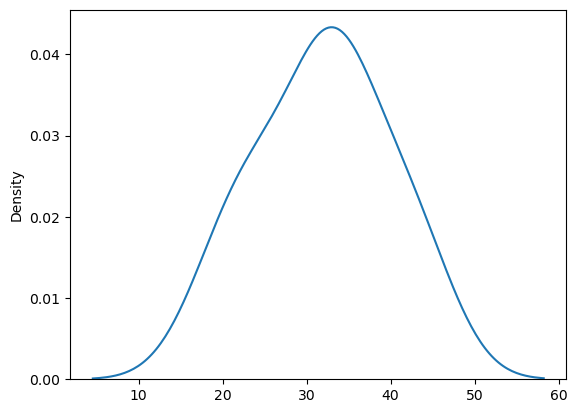

In [13]:
sns.kdeplot(sample_mean)

**upto now: we know sample mean, sample std and no: of trials (n) now we need to find critical value which is t(alpha/2). so for that we go to t-table  and check for 95% and 30 sample size and we got value= 2.042, yeh t(alpha/2) ki value hai. so now apply formula of t-distribution**

In [21]:
lower_limit = sample_mean - (2.042*sample_std)/np.sqrt(30)
upper_limit = sample_mean + (2.042*sample_std)/np.sqrt(30)
print("the range is", lower_limit, "-", upper_limit)

the range is 16.96558249134152 - 46.89897150865848


**what we are saying that original population ka mean is range mein aane ki chance 95% hai (from empirical rule)**

**so what we are doing now to find actual population mean matlab Fare column ka mean**

In [23]:
df["Fare"].mean()   # which lies in this above calculated range 

np.float64(33.29547928134557)

**same question but tell me if cofidence level = 50% rather than 95%?**

-> so uske liye again t table mein n=30 and 50% ke ke liye t(aplha/2) ki value nikaaldo i.e. 0.683 so again formula mein daaldoge i.e. upper and lower limit

# 1. One sample t-test:

In [29]:
from scipy.stats import t
# set the t value and degree of freedom:
t_value = -1.25   # from formula for one sample t test
df = 24
# calculate the CDF value: which is area to the left side of normal distribution curve
cdf_value = t.cdf(t_value, df)
print(cdf_value)

0.1116757390828102


**left area=a1= 0.111 so similarly right area= 0.111 and total p_value= a1+a2 = 0.22 which is greater than 0.05 so we cant reject the null hypothesis**

# EXAMPLE: now use same method in titanic dataset where you claim that average age of passenger is 35

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [4]:
train = pd.read_csv("../datasets/train_kaggle.csv")
test = pd.read_csv("../datasets/test_kaggle.csv")

In [5]:
#now merge both datas to complete the table and shuffle them using sample:

final_df = pd.concat([train,test]).sample(1309)

In [6]:
age = final_df["Age"].dropna() 

In [8]:
# lets take 25 ages as sample:

sample_age = age.sample(25).values
sample_age

array([29.  , 35.  , 54.  , 31.  , 18.  , 17.  ,  0.83, 57.  , 24.  ,
       38.  , 38.  , 28.  , 32.  , 27.  , 19.  , 20.  , 22.  , 36.  ,
       21.  , 39.  , 29.  , 21.  ,  4.  , 54.  , 18.  ])

**Step1: Now set the null and alternate hypothesis:**

H0: the mean age is 35

H1: the mean age is less than 35      # single tailed test

**As we take 25 samples to humein nhi pata yeh distribution normal hai ynn nhi.**

**Step2: So for that now check the normality using SHAPIRO-WILK TEST:**
in this test if p value< 0.05 then yeh distribution normal nhi hai otherwise not

In [21]:
from scipy.stats import shapiro
shapiro_age = shapiro(sample_age)
shapiro_age

#Shapiro-wilk test return two things : test statistics and p value

ShapiroResult(statistic=np.float64(0.95387719307418), pvalue=np.float64(0.30600516513781706))

**pvalue=np.float64(0.30600516513781706)> 0.05 : so yeh distribution normal hai**

**Step3: as std deviation nhi hai to ab t-test nikaalna hai for one sample t test**

In [19]:
pop_mean = 35    # population mean jo hum t value find krne ke liye use krenge

from scipy.stats import stats
t_stats, p_value = stats.ttest_1samp(sample_age, pop_mean)          # as this one sample t test
print("t_statistics: ", t_stats)
print("p_value:", p_value/2)     
# p_value/2 isliye kiya kyunki alternate hypothesis mein "<" hai so single tailed test hua to ek ka nikaalne ke liye 2 se devide krdiya 

alpha= 0.05
if p_value<alpha:
    print("reject the null hypothesis")
else:
    print("failed to reject the null hypothesis")

t_statistics:  -2.3624446261756704
p_value: 0.013301543476732618
reject the null hypothesis


C:\Users\adity\AppData\Local\Temp\ipykernel_1696\2587525536.py:4: DeprecationWarning: Please import `ttest_1samp` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  t_stats, p_value = stats.ttest_1samp(sample_age, pop_mean)          # as this one sample t test


In [20]:
# we accept alternate hypothesis which is average age is less than 35, we can also check that if its true or not:

age.mean()

np.float64(29.881137667304014)

# 2. Independent 2 sample t-test:

In [27]:
# input datas in list :
desktop_users = [12,15,18,16,20,17,14,22,19,21,23,18,25,17,16,24,20,19,22,18,15,14,23,16,12,21,19,17,20,14]
mobile_users  = [10,12,14,13,16,15,11,17,14,16,18,14,20,15,14,19,16,15,17,14,12,11,18,15,10,16,15,13,16,11]

**Step1: Now set the null and alternate hypothesis:**

H0: there is no diference between avg time spent on their website through desktop or mobile users

H1: there is a significant difference  # two tailed test

In [28]:
# Step2:  perform shapiro test: to check normal distribution or not
shapiro_desktop = shapiro(desktop_users)
shapiro_mobile = shapiro(mobile_users)

print("Shapiro test for desktop_users:" , shapiro_desktop)
print("Shapiro test for mobile_users:" , shapiro_mobile)

Shapiro test for desktop_users: ShapiroResult(statistic=np.float64(0.9783115512411942), pvalue=np.float64(0.7791003299808725))
Shapiro test for mobile_users: ShapiroResult(statistic=np.float64(0.9714355768676655), pvalue=np.float64(0.5791606602037616))


**Step3: to check if they have equal variance or not, for that we use LEVENE'S TEST:** if p value<0.05 : then they dont have equal variance but if p value> 0.05: then they have equal variance

In [25]:
from scipy.stats import levene

In [26]:
levene_test = levene(desktop_users, mobile_users)
levene_test

LeveneResult(statistic=np.float64(2.94395488191752), pvalue=np.float64(0.09153720526741761))

**Step4: as pvalue>0.05: so they have equal variance so now we can find t value as now formula get changed**

In [30]:
# set t value and degree of freedom for this method:

t_value = -5.25    #vaise positive value hai but left side area nikaalne ke liye "-" choose kiya
df= 58     # df = n1+n2-2

cdf_value = t.cdf(t_value, df)
p_value = cdf_value*2
p_value

np.float64(2.256369746933224e-06)

**very small value of p because it ends with e^-0.06 as compare to 0.05, so we reject the null hypothesis**

# Example: now use titanic dataset where you claim that avg age of male > avg age of female

In [31]:
train = pd.read_csv("../datasets/train_kaggle.csv")
test = pd.read_csv("../datasets/test_kaggle.csv")

In [32]:
#now merge both datas to complete the table and shuffle them using sample:

final_df = pd.concat([train,test]).sample(1309)

In [35]:
#extract male and female age:

male_age = final_df[final_df["Sex"] == "male"]["Age"].dropna()
female_age = final_df[final_df["Sex"] == "female"]["Age"].dropna()

In [36]:
sample_male = male_age.sample(25)
sample_female = female_age.sample(25)

**Step1: Set null and alternate hypothesis**

H0: average age of male = average age of female

H1: Average age of male > average age of female

alpha = 0.05

In [37]:
#step 2: Perform shapiro wilk test to check normality 
shapiro_male = shapiro(sample_male)
shapiro_female = shapiro(sample_female)

print("Shapiro test for male age is:", shapiro_male)
print("Shapiro test for female age is:", shapiro_female)

Shapiro test for male age is: ShapiroResult(statistic=np.float64(0.9402367609242174), pvalue=np.float64(0.149906418108737))
Shapiro test for female age is: ShapiroResult(statistic=np.float64(0.9535601236589939), pvalue=np.float64(0.3011099245083698))


**p value for both is > 0.05: so distribution is normal**

In [38]:
#step 3: perform levene test to check euivariance:
levene_test = levene(sample_male, sample_female)
levene_test

LeveneResult(statistic=np.float64(2.6766646613834566), pvalue=np.float64(0.10837009178354481))

**pvalue > 0.05: so now we can move further as they have same variance, so now we have to find value of t using independent 2 sample t test**

In [43]:
#step 4: find t value:
import scipy.stats as stats 
t_stat, p_value = stats.ttest_ind(sample_male,sample_female)
print("t_statistics :", t_stat)
print("p_value :", p_value/2)      # again devide by 2 single tailed test ke liye kiya
alpha= 0.05
if p_value<alpha:
    print("reject the null hypothesis")
else:
    print("failed to reject the null hypothesis")

t_statistics : 1.53188715485223
p_value : 0.06605758155586179
failed to reject the null hypothesis


# 3. Paired dependent 2 sample t test:

In [55]:
before = np.array([80,92,75,68,85,78,73,90,70,86,76,84,82,77,91])
after  = np.array([78,93,81,67,88,76,74,91,69,88,77,81,80,79,88])

**Step1: Set null and alternate hypothesis**

H0: average weight before = average weight after  

H1: Average weight before > average weight after      # single tailed test 

alpha = 0.05

**Remember : paired test mein hum difference ke upar normality check krte hain ki vo normal distribution hai yn nhi means iske difference ke upar shapiro wilk test apply krna for checking normality**

In [56]:
difference = before - after

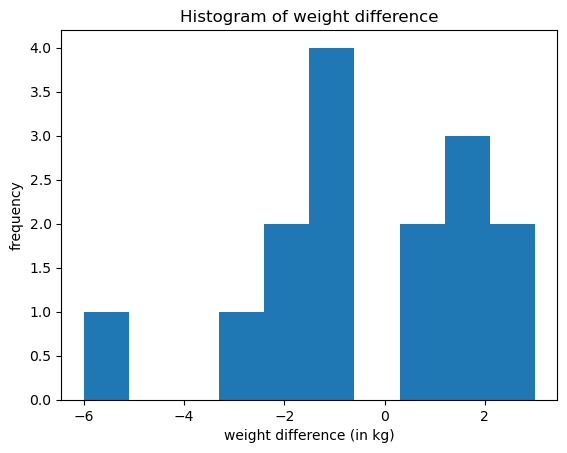

In [57]:
plt.hist(difference)
plt.title("Histogram of weight difference")
plt.xlabel("weight difference (in kg)")
plt.ylabel("frequency")
plt.show()

In [58]:
#now shapiro test inke difference ka lena hai:

shapiro_test = shapiro(difference)
print("Shapiro-Wilk test:", shapiro_test)

Shapiro-Wilk test: ShapiroResult(statistic=np.float64(0.9239089977125381), pvalue=np.float64(0.22090200967559093))


**that means iska difference normally distriuted hai, so now apply test**

In [59]:
# Step 2: now find mean of difference of weight and std deviation of difference of weight again formaula change for finding t

mean_diff = np.mean(difference)
std_diff  = np.std(difference, ddof = 1)
n = len(difference)
df = n-1   # degree of freedom
alpha= 0.05

t_statistics = mean_diff / (std_diff/np.sqrt(n))

In [60]:
t_statistics

np.float64(-0.30825739964255383)

In [62]:
p_value = stats.t.cdf(t_statistics, df)
p_value

np.float64(0.3812126628546365)

**since this p value > 0.05: we failed to reject null hypothesis**